In [1]:
import pandas as pd
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt

import pyspark
from pyspark.sql.functions import col
from pyspark.sql import SparkSession
from pyspark.sql import functions as F
from pyspark.sql.functions import col, when, regexp_replace, to_date, count, sum as spark_sum, isnan
from pyspark.sql.types import StringType, IntegerType, FloatType, DateType

In [2]:
# Initialize SparkSession
spark = pyspark.sql.SparkSession.builder \
    .appName("dev") \
    .master("local[*]") \
    .getOrCreate()

# Set log level to ERROR to hide warnings
spark.sparkContext.setLogLevel("ERROR")

Using Spark's default log4j profile: org/apache/spark/log4j2-defaults.properties
Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
26/05/21 15:03:41 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable
26/05/21 15:03:42 WARN Utils: Service 'SparkUI' could not bind on port 4040. Attempting port 4041.


# 1. Clickstream Dataset

In [3]:
clickstream_df = (
    spark.read
    .option("header", True)
    .option("inferSchema", True)
    .option("sep", ",")
    .csv("./datamart/bronze/feature_clickstream/bronze_clickstream_*.csv")
)
clickstream_df.printSchema()
print("Row count:", clickstream_df.count())

root
 |-- fe_1: integer (nullable = true)
 |-- fe_2: integer (nullable = true)
 |-- fe_3: integer (nullable = true)
 |-- fe_4: integer (nullable = true)
 |-- fe_5: integer (nullable = true)
 |-- fe_6: integer (nullable = true)
 |-- fe_7: integer (nullable = true)
 |-- fe_8: integer (nullable = true)
 |-- fe_9: integer (nullable = true)
 |-- fe_10: integer (nullable = true)
 |-- fe_11: integer (nullable = true)
 |-- fe_12: integer (nullable = true)
 |-- fe_13: integer (nullable = true)
 |-- fe_14: integer (nullable = true)
 |-- fe_15: integer (nullable = true)
 |-- fe_16: integer (nullable = true)
 |-- fe_17: integer (nullable = true)
 |-- fe_18: integer (nullable = true)
 |-- fe_19: integer (nullable = true)
 |-- fe_20: integer (nullable = true)
 |-- Customer_ID: string (nullable = true)
 |-- snapshot_date: date (nullable = true)



[Stage 2:>                                                        (0 + 12) / 12]

Row count: 215376


In [4]:
clickstream_df.show(5)

+----+----+----+----+----+----+----+----+----+-----+-----+-----+-----+-----+-----+-----+-----+-----+-----+-----+-----------+-------------+
|fe_1|fe_2|fe_3|fe_4|fe_5|fe_6|fe_7|fe_8|fe_9|fe_10|fe_11|fe_12|fe_13|fe_14|fe_15|fe_16|fe_17|fe_18|fe_19|fe_20|Customer_ID|snapshot_date|
+----+----+----+----+----+----+----+----+----+-----+-----+-----+-----+-----+-----+-----+-----+-----+-----+-----+-----------+-------------+
|  71| 243|  89| 149| 202|  56| 149| 207| 232|  111|  179|  340|  -17|  100|  115|   68|   39|   87|  -74|  240| CUS_0x1037|   2024-03-01|
| -60|  65|  30| -56|  25| 206|  68| 157| -36|   81|   77|   66|  169|   98|   75|  268|   95|   19|  151|  234| CUS_0x1069|   2024-03-01|
|  50|  76| 115| 114| -57| 136|  33|  69| 175|   92|  218|  151|   30|  204|  268|  181|  333|   70|  190|   23| CUS_0x114a|   2024-03-01|
|   1| 245|  72| 247| 212|  80| 144| 138|   7|  -86|  284|   35|  -46|  159|   81|   58|  340|   38|   66|  -36| CUS_0x1184|   2024-03-01|
|   8| 138| 164| 147| 184| 

In [5]:
clickstream_df.describe()

DataFrame[summary: string, fe_1: string, fe_2: string, fe_3: string, fe_4: string, fe_5: string, fe_6: string, fe_7: string, fe_8: string, fe_9: string, fe_10: string, fe_11: string, fe_12: string, fe_13: string, fe_14: string, fe_15: string, fe_16: string, fe_17: string, fe_18: string, fe_19: string, fe_20: string, Customer_ID: string]

In [6]:
# check null column
clickstream_df.select([
    spark_sum(col(c).isNull().cast("int")).alias(c)
    for c in clickstream_df.columns
]).show()

[Stage 6:=========>                                               (2 + 10) / 12]

+----+----+----+----+----+----+----+----+----+-----+-----+-----+-----+-----+-----+-----+-----+-----+-----+-----+-----------+-------------+
|fe_1|fe_2|fe_3|fe_4|fe_5|fe_6|fe_7|fe_8|fe_9|fe_10|fe_11|fe_12|fe_13|fe_14|fe_15|fe_16|fe_17|fe_18|fe_19|fe_20|Customer_ID|snapshot_date|
+----+----+----+----+----+----+----+----+----+-----+-----+-----+-----+-----+-----+-----+-----+-----+-----+-----+-----------+-------------+
|   0|   0|   0|   0|   0|   0|   0|   0|   0|    0|    0|    0|    0|    0|    0|    0|    0|    0|    0|    0|          0|            0|
+----+----+----+----+----+----+----+----+----+-----+-----+-----+-----+-----+-----+-----+-----+-----+-----+-----+-----------+-------------+



In [7]:
# how many rows per snapshot month?
clickstream_df.groupBy("snapshot_date").count().orderBy("snapshot_date").show(30)

[Stage 9:>                                                        (0 + 12) / 12]

+-------------+-----+
|snapshot_date|count|
+-------------+-----+
|   2023-01-01| 8974|
|   2023-02-01| 8974|
|   2023-03-01| 8974|
|   2023-04-01| 8974|
|   2023-05-01| 8974|
|   2023-06-01| 8974|
|   2023-07-01| 8974|
|   2023-08-01| 8974|
|   2023-09-01| 8974|
|   2023-10-01| 8974|
|   2023-11-01| 8974|
|   2023-12-01| 8974|
|   2024-01-01| 8974|
|   2024-02-01| 8974|
|   2024-03-01| 8974|
|   2024-04-01| 8974|
|   2024-05-01| 8974|
|   2024-06-01| 8974|
|   2024-07-01| 8974|
|   2024-08-01| 8974|
|   2024-09-01| 8974|
|   2024-10-01| 8974|
|   2024-11-01| 8974|
|   2024-12-01| 8974|
+-------------+-----+



# 2. Attributes dataset

In [8]:
attributes_df = (
    spark.read
    .option("header", True)
    .option("inferSchema", True)
    .option("sep", ",")
    .csv("./datamart/bronze/features_attributes/bronze_attributes_*.csv")
)
attributes_df.printSchema()
print("Row count:", attributes_df.count())

root
 |-- Customer_ID: string (nullable = true)
 |-- Name: string (nullable = true)
 |-- Age: string (nullable = true)
 |-- SSN: string (nullable = true)
 |-- Occupation: string (nullable = true)
 |-- snapshot_date: date (nullable = true)

Row count: 11974


In [9]:
attributes_df.show(truncate=False)

+-----------+----------------+----+-----------+------------+-------------+
|Customer_ID|Name            |Age |SSN        |Occupation  |snapshot_date|
+-----------+----------------+----+-----------+------------+-------------+
|CUS_0x10ac |Zhouy           |29  |780-50-4730|Developer   |2024-08-01   |
|CUS_0x10c5 |Moony           |24  |041-74-6785|_______     |2024-08-01   |
|CUS_0x1145 |Blenkinsopr     |24  |426-31-9194|Teacher     |2024-08-01   |
|CUS_0x11ac |Liana B.v       |26_ |835-92-7751|Journalist  |2024-08-01   |
|CUS_0x122c |Papadimasf      |48  |883-73-9594|Entrepreneur|2024-08-01   |
|CUS_0x1274 |Whited          |5656|298-61-0480|Scientist   |2024-08-01   |
|CUS_0x1288 |Taylorq         |34_ |609-85-2725|Doctor      |2024-08-01   |
|CUS_0x12cc |Lauren Tarat    |30  |761-36-5969|Developer   |2024-08-01   |
|CUS_0x1338 |Olivia Orang    |40  |250-62-9181|_______     |2024-08-01   |
|CUS_0x1370 |Rothackerb      |32  |710-06-0138|Writer      |2024-08-01   |
|CUS_0x1378 |Alan Wheatle

### Check null column


In [10]:
attributes_df.select([
    spark_sum(col(c).isNull().cast("int")).alias(c)
    for c in attributes_df.columns
]).show()

+-----------+----+---+---+----------+-------------+
|Customer_ID|Name|Age|SSN|Occupation|snapshot_date|
+-----------+----+---+---+----------+-------------+
|          0|   0|  0|  0|         0|            0|
+-----------+----+---+---+----------+-------------+



In [11]:
attributes_df.groupBy("Occupation").count().orderBy(F.desc("count")).show(50, truncate=False)

+-------------+-----+
|Occupation   |count|
+-------------+-----+
|_______      |846  |
|Lawyer       |785  |
|Architect    |766  |
|Accountant   |763  |
|Engineer     |754  |
|Teacher      |751  |
|Media_Manager|750  |
|Mechanic     |750  |
|Scientist    |746  |
|Developer    |746  |
|Entrepreneur |744  |
|Journalist   |741  |
|Doctor       |729  |
|Musician     |709  |
|Manager      |700  |
|Writer       |694  |
+-------------+-----+



In [12]:
print("Count SSN dirty rows: ", attributes_df.filter(col("SSN") == "#F%$D@*&8").count())
print("Count Occupation dirty rows: ", attributes_df.filter(col("Occupation") == "_______").count())


Count SSN dirty rows:  676
Count Occupation dirty rows:  846


### Clean up messy text in SSN, Occupation, Age, then cast Age to int

In [13]:
attributes_cleaned_df = (
    attributes_df
    .filter(col("SSN") != "#F%$D@*&8")
    .drop("SSN")  # PII
    .filter(col("Occupation") != "_______")
    .withColumn("Age", regexp_replace(col("Age").cast("string"), "[^0-9-]", ""))
    .withColumn("Age", col("Age").cast(IntegerType()))
)
attributes_cleaned_df.printSchema()
print("Rows after clean:", attributes_cleaned_df.count())
attributes_cleaned_df.show(5)

root
 |-- Customer_ID: string (nullable = true)
 |-- Name: string (nullable = true)
 |-- Age: integer (nullable = true)
 |-- Occupation: string (nullable = true)
 |-- snapshot_date: date (nullable = true)

Rows after clean: 10501
+-----------+-----------+----+------------+-------------+
|Customer_ID|       Name| Age|  Occupation|snapshot_date|
+-----------+-----------+----+------------+-------------+
| CUS_0x10ac|      Zhouy|  29|   Developer|   2024-08-01|
| CUS_0x1145|Blenkinsopr|  24|     Teacher|   2024-08-01|
| CUS_0x11ac|  Liana B.v|  26|  Journalist|   2024-08-01|
| CUS_0x122c| Papadimasf|  48|Entrepreneur|   2024-08-01|
| CUS_0x1274|     Whited|5656|   Scientist|   2024-08-01|
+-----------+-----------+----+------------+-------------+
only showing top 5 rows


In [14]:
# unique customer in the dataset. Make sure no multiplee cust entries
print("Unique customers:", attributes_cleaned_df.select("Customer_ID").distinct().count())

[Stage 34:>                                                       (0 + 12) / 12]

Unique customers: 10501


### Double check if the dirty rows are gone

In [15]:
# SSN column dropped in cleaning step (PII) — no check needed

# Check Occupation underscores are gone
print("Bad Occupation rows:", attributes_cleaned_df.filter(col("Occupation") == "_______").count())

# Check Age
print("Rows with _ in Age:", attributes_cleaned_df.filter(col("Age").rlike("_")).count())
attributes_cleaned_df.select("Age").describe().show()


Bad Occupation rows: 0
Rows with _ in Age: 0
+-------+------------------+
|summary|               Age|
+-------+------------------+
|  count|             10501|
|   mean|106.28416341300829|
| stddev| 670.4103945705391|
|    min|              -500|
|    max|              8678|
+-------+------------------+



### Visualisation

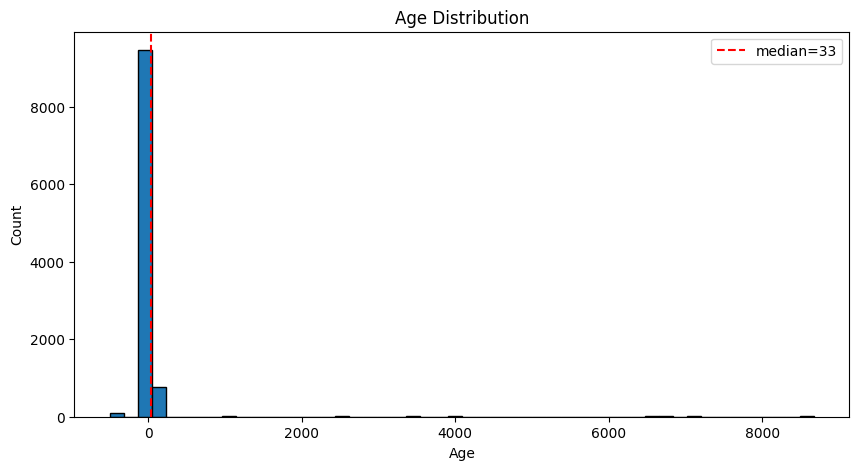

rows with Age > 70: 181
rows with Age < 18 : 639
rows with Age >= 18 and <= 70: 9681


In [16]:
# visualize age distribution
ages = attributes_cleaned_df.select("Age").toPandas()

plt.figure(figsize=(10, 5))
plt.hist(ages["Age"].dropna(), bins=50, edgecolor="black")
plt.title("Age Distribution")
plt.xlabel("Age")
plt.ylabel("Count")
plt.axvline(ages["Age"].median(), color="red", linestyle="--", label=f"median={ages['Age'].median():.0f}")
plt.legend()
plt.show()

# check unrealistic age rows
print("rows with Age > 70:", (ages["Age"] > 70).sum())
print("rows with Age < 18 :", (ages["Age"] < 18).sum())
print(
    "rows with Age >= 18 and <= 70:",
    ((ages["Age"] >= 18) & (ages["Age"] <= 70)).sum()
)

### Drop age that is below 18 and above 70

In [17]:
before = attributes_cleaned_df.count()
attributes_cleaned_df = attributes_cleaned_df.filter((col("Age") >= 18) & (col("Age") <= 70))
after = attributes_cleaned_df.count()
print(f"Rows after Age filter: {after} (dropped {before - after})")

Rows after Age filter: 9681 (dropped 820)


# 3. Financials Dataset

In [18]:
# # ===== PySpark version =====
financials_df = (
    spark.read
    .option("header", True)
    .option("inferSchema", True)
    .option("sep", ",")
    .csv("./datamart/bronze/features_financials/bronze_financials_*.csv")
)
# financials_df.printSchema()
# print("Row count:", financials_df.count())
# financials_df.show(5, truncate=False)

# ===== Pandas mirror (easier to read) =====
financials_pdf = financials_df.toPandas()
financials_pdf.head()

,Customer_ID,Annual_Income,Monthly_Inhand_Salary,Num_Bank_Accounts,Num_Credit_Card,Interest_Rate,Num_of_Loan,Type_of_Loan,Delay_from_due_date,Num_of_Delayed_Payment,...,Credit_Mix,Outstanding_Debt,Credit_Utilization_Ratio,Credit_History_Age,Payment_of_Min_Amount,Total_EMI_per_month,Amount_invested_monthly,Payment_Behaviour,Monthly_Balance,snapshot_date
0,CUS_0x10ac,16718.645,1270.220417,7,3,15,4,"Credit-Builder Loan, Credit-Builder Loan, Home...",26,11,...,_,853.41,31.397339,16 Years and 3 Months,No,50.961936,36.41309208442618,!@9#%8,319.6470136821514,2024-08-01
1,CUS_0x10c5,158623.16,13180.596667,2,7,10,1,Payday Loan,10,5,...,Good,1134.83,41.796800,30 Years and 2 Months,No,91.033905,282.71868909757717,High_spent_Medium_value_payments,1194.3070725894725,2024-08-01
2,CUS_0x1145,17975.32,1444.943333,6,5,32,9,"Student Loan, Payday Loan, Not Specified, Mort...",61,25,...,Bad,1263.1,25.681798,12 Years and 5 Months,Yes,76.450325,176.77621007546128,Low_spent_Small_value_payments,181.26779867070005,2024-08-01
3,CUS_0x11ac,69136.54,5902.378333,3,4,14,0,None,14,18,...,Standard,478.85,32.103164,17 Years and 5 Months,Yes,0.000000,435.93700154823983,Low_spent_Small_value_payments,444.30083178509364,2024-08-01
4,CUS_0x122c,36346.13,3188.844167,8,6,11,3,"Credit-Builder Loan, Home Equity Loan, and Aut...",21,15,...,Good,1252.46,28.066704,22 Years and 2 Months,NM,89.061554,110.50970251432872,High_spent_Medium_value_payments,369.3131601102126,2024-08-01


In [19]:
financials_pdf.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11974 entries, 0 to 11973
Data columns (total 22 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Customer_ID               11974 non-null  object 
 1   Annual_Income             11974 non-null  object 
 2   Monthly_Inhand_Salary     11974 non-null  float64
 3   Num_Bank_Accounts         11974 non-null  int32  
 4   Num_Credit_Card           11974 non-null  int32  
 5   Interest_Rate             11974 non-null  int32  
 6   Num_of_Loan               11974 non-null  object 
 7   Type_of_Loan              10606 non-null  object 
 8   Delay_from_due_date       11974 non-null  int32  
 9   Num_of_Delayed_Payment    11974 non-null  object 
 10  Changed_Credit_Limit      11974 non-null  object 
 11  Num_Credit_Inquiries      11974 non-null  float64
 12  Credit_Mix                11974 non-null  object 
 13  Outstanding_Debt          11974 non-null  object 
 14  Credit

In [20]:
financials_pdf.describe()

,Monthly_Inhand_Salary,Num_Bank_Accounts,Num_Credit_Card,Interest_Rate,Delay_from_due_date,Num_Credit_Inquiries,Credit_Utilization_Ratio,Total_EMI_per_month
count,11974.000000,11974.000000,11974.000000,11974.000000,11974.000000,11974.000000,11974.000000,11974.000000
mean,4194.017661,16.936780,23.478370,72.846167,21.051695,26.260732,32.342962,1496.271736
std,3187.070393,114.029124,133.184533,465.894239,14.884603,181.788874,5.155056,8601.266480
min,303.645417,-1.000000,0.000000,1.000000,-5.000000,0.000000,20.100770,0.000000
25%,1623.436354,3.000000,4.000000,8.000000,10.000000,4.000000,28.051042,31.605808
50%,3088.674583,6.000000,6.000000,14.000000,18.000000,6.000000,32.413992,72.811924
75%,5967.644583,7.000000,7.000000,20.000000,28.000000,10.000000,36.612921,169.588227
max,15204.633333,1747.000000,1499.000000,5789.000000,67.000000,2554.000000,48.199824,81971.000000


### Missing value: 
- ### Type_of_Loan null -> 1426 row

In [21]:
# # ===== PySpark version =====
# financials_df.select([
#     spark_sum(col(c).isNull().cast("int")).alias(c)
#     for c in financials_df.columns
# ]).show()

# ===== Pandas mirror =====
print("\n--- Pandas null counts ---")
financials_pdf.isnull().sum()


--- Pandas null counts ---


Customer_ID                    0
Annual_Income                  0
Monthly_Inhand_Salary          0
Num_Bank_Accounts              0
Num_Credit_Card                0
Interest_Rate                  0
Num_of_Loan                    0
Type_of_Loan                1368
Delay_from_due_date            0
Num_of_Delayed_Payment         0
Changed_Credit_Limit           0
Num_Credit_Inquiries           0
Credit_Mix                     0
Outstanding_Debt               0
Credit_Utilization_Ratio       0
Credit_History_Age             0
Payment_of_Min_Amount          0
Total_EMI_per_month            0
Amount_invested_monthly        0
Payment_Behaviour              0
Monthly_Balance                0
snapshot_date                  0
dtype: int64

In [22]:
# ===== PySpark version =====
# Credit_Mix sentinel
# financials_df.groupBy("Credit_Mix").count().orderBy(F.desc("count")).show(truncate=False)

# ===== Pandas mirror =====
financials_pdf["Credit_Mix"].value_counts(dropna=False)

Credit_Mix
Standard    4287
Good        2918
_           2505
Bad         2264
Name: count, dtype: int64

In [23]:
# ===== PySpark version =====
# financials_df.groupBy("Payment_Behaviour").count().orderBy(F.desc("count")).show(truncate=False)

# ===== Pandas mirror =====
print("\n--- Pandas Payment_Behaviour value counts ---")
financials_pdf["Payment_Behaviour"].value_counts(dropna=False)


--- Pandas Payment_Behaviour value counts ---


Payment_Behaviour
Low_spent_Small_value_payments      3064
High_spent_Medium_value_payments    2138
High_spent_Large_value_payments     1622
Low_spent_Medium_value_payments     1618
High_spent_Small_value_payments     1337
Low_spent_Large_value_payments      1242
!@9#%8                               953
Name: count, dtype: int64

In [24]:
# ===== PySpark version =====
# Type_of_Loan is multi-valued, comma-separated — count distinct loan-type tokens
# from pyspark.sql.functions import split, explode, trim, lower
# (
#     financials_df
#     .filter(col("Type_of_Loan").isNotNull())
#     .withColumn("loan_type", explode(split(regexp_replace(col("Type_of_Loan"), "and ", ""), ",")))
#     .withColumn("loan_type", trim(lower(col("loan_type"))))
#     .groupBy("loan_type").count()
#     .orderBy(F.desc("count"))
#     .show(truncate=False)
# )

# ===== Pandas mirror =====
print("\n--- Pandas exploded loan types ---")
(
    financials_pdf["Type_of_Loan"]
    .dropna()
    .str.replace("and ", "", regex=False)
    .str.split(",")
    .explode()
    .str.strip()
    .str.lower()
    .value_counts()
)


--- Pandas exploded loan types ---


Type_of_Loan
credit-builder loan        4857
payday loan                4851
not specified              4705
personal loan              4664
home equity loan           4663
mortgage loan              4659
student loan               4645
debt consolidation loan    4641
auto loan                  4546
Name: count, dtype: int64

In [25]:
# # Strip trailing underscores from numeric-but-string columns, then cast to float
# numeric_dirty_cols = [
#     "Annual_Income", "Num_of_Loan", "Num_of_Delayed_Payment",
#     "Outstanding_Debt", "Amount_invested_monthly", "Monthly_Balance",
# ]

# # ===== PySpark version =====
# financials_cast = financials_df
# for c in numeric_dirty_cols:
#     financials_cast = financials_cast.withColumn(
#         c,
#         regexp_replace(col(c).cast("string"), "[^0-9.\\-]", "").cast(FloatType())
#     )

# financials_cast.select(numeric_dirty_cols).describe().show()

# # ===== Pandas mirror =====
# financials_cast_pdf = financials_pdf.copy()
# for c in numeric_dirty_cols:
#     cleaned = (
#         financials_cast_pdf[c].astype(str)
#         .str.replace(r"[^0-9.\-]", "", regex=True)
#     )
#     financials_cast_pdf[c] = pd.to_numeric(cleaned, errors="coerce")
# print("\n--- Pandas describe ---")
# financials_cast_pdf[numeric_dirty_cols].describe()

In [26]:
financials_pdf.describe()

,Monthly_Inhand_Salary,Num_Bank_Accounts,Num_Credit_Card,Interest_Rate,Delay_from_due_date,Num_Credit_Inquiries,Credit_Utilization_Ratio,Total_EMI_per_month
count,11974.000000,11974.000000,11974.000000,11974.000000,11974.000000,11974.000000,11974.000000,11974.000000
mean,4194.017661,16.936780,23.478370,72.846167,21.051695,26.260732,32.342962,1496.271736
std,3187.070393,114.029124,133.184533,465.894239,14.884603,181.788874,5.155056,8601.266480
min,303.645417,-1.000000,0.000000,1.000000,-5.000000,0.000000,20.100770,0.000000
25%,1623.436354,3.000000,4.000000,8.000000,10.000000,4.000000,28.051042,31.605808
50%,3088.674583,6.000000,6.000000,14.000000,18.000000,6.000000,32.413992,72.811924
75%,5967.644583,7.000000,7.000000,20.000000,28.000000,10.000000,36.612921,169.588227
max,15204.633333,1747.000000,1499.000000,5789.000000,67.000000,2554.000000,48.199824,81971.000000


In [27]:
# pdf = financials_pdf[[
#     "Annual_Income", "Monthly_Inhand_Salary",
#   "Num_Bank_Accounts", "Num_Credit_Card", "Interest_Rate",
#   "Num_of_Loan", "Delay_from_due_date", "Num_of_Delayed_Payment",
#   "Changed_Credit_Limit", "Num_Credit_Inquiries",
#   "Outstanding_Debt", "Credit_Utilization_Ratio",
#   "Total_EMI_per_month", "Amount_invested_monthly",
#   "Monthly_Balance",
# ]]

# fig, ax = plt.subplots(1, 3, figsize=(18, 5))

# ax[0].hist(pdf["Annual_Income"].dropna(), bins=50)
# ax[0].set_title("Annual Income")

# ax[1].hist(pdf["Monthly_Inhand_Salary"].dropna(), bins=50)
# ax[1].set_title("Monthly Salary")

# ax[2].hist(pdf["Credit_Utilization_Ratio"].dropna(), bins=50)
# ax[2].set_title("Credit Utilization")

# plt.tight_layout()
# plt.show()

In [28]:
numeric_cols = [
  "Annual_Income", "Monthly_Inhand_Salary",
  "Num_Bank_Accounts", "Num_Credit_Card", "Interest_Rate",
  "Num_of_Loan", "Delay_from_due_date", "Num_of_Delayed_Payment",
  "Changed_Credit_Limit", "Num_Credit_Inquiries",
  "Outstanding_Debt", "Credit_Utilization_Ratio",
  "Total_EMI_per_month", "Amount_invested_monthly", "Monthly_Balance"
]

def iqr_report(financials_pdf, cols):
  rows = []
  for c in cols:
      s = pd.to_numeric(financials_pdf[c], errors="coerce").dropna()
      q1, q3 = s.quantile(0.25), s.quantile(0.75)
      iqr = q3 - q1
      lo, hi = q1 - 1.5 * iqr, q3 + 1.5 * iqr
      n_out = ((s < lo) | (s > hi)).sum()
      rows.append({
          "column": c,
          "min": s.min(), "Q1": q1, "median": s.median(), "Q3": q3, "max": s.max(),
          "IQR": iqr, "lower_bound": lo, "upper_bound": hi,
          "n_outliers": n_out, "pct_outliers": round(100 * n_out / len(s), 2),
      })
  return pd.DataFrame(rows).set_index("column")

iqr_report(financials_pdf, numeric_cols)

,min,Q1,median,Q3,max,IQR,lower_bound,upper_bound,n_outliers,pct_outliers
column,,,,,,,,,,
Annual_Income,7005.930000,19364.180000,37433.105000,73093.310000,2.383470e+07,53729.130000,-61229.515000,153687.005000,303,2.72
Monthly_Inhand_Salary,303.645417,1623.436354,3088.674583,5967.644583,1.520463e+04,4344.208229,-4892.875990,12483.956927,237,1.98
Num_Bank_Accounts,-1.000000,3.000000,6.000000,7.000000,1.747000e+03,4.000000,-3.000000,13.000000,161,1.34
Num_Credit_Card,0.000000,4.000000,6.000000,7.000000,1.499000e+03,3.000000,-0.500000,11.500000,284,2.37
Interest_Rate,1.000000,8.000000,14.000000,20.000000,5.789000e+03,12.000000,-10.000000,38.000000,260,2.17
Num_of_Loan,-100.000000,1.000000,3.000000,5.000000,1.495000e+03,4.000000,-5.000000,11.000000,547,4.81
Delay_from_due_date,-5.000000,10.000000,18.000000,28.000000,6.700000e+01,18.000000,-17.000000,55.000000,487,4.07
Num_of_Delayed_Payment,-3.000000,9.000000,14.000000,18.000000,4.293000e+03,9.000000,-4.500000,31.500000,99,0.85
Changed_Credit_Limit,-6.490000,5.400000,9.420000,14.960000,3.697000e+01,9.560000,-8.940000,29.300000,77,0.66


### Data Cleaning

In [29]:
# Clean financials_df: strip "_" / swap "," -> ".", empty -> null, then cast
from pyspark.sql.functions import when

def clean_num(c, sep_swap=False, dtype=FloatType()):
    #replace _ with ""
    e = regexp_replace(col(c), "_", "")
    
    # replace , with .
    if sep_swap:
        e = regexp_replace(e, ",", ".")

    #remove _
    e = when(e == "", None).otherwise(e) 
    return e.cast(dtype)

financials_cleaned_df = (
    financials_df
    .withColumn("Annual_Income", F.round(clean_num("Annual_Income"), 2))
    .withColumn("Monthly_Inhand_Salary", clean_num("Monthly_Inhand_Salary", sep_swap=True))
    .withColumn("Num_of_Loan", clean_num("Num_of_Loan", dtype=IntegerType()))
    .withColumn("Num_of_Delayed_Payment", clean_num("Num_of_Delayed_Payment", dtype=IntegerType()))
    .filter(col("Changed_Credit_Limit") != "_")
    .withColumn("Changed_Credit_Limit", F.round(clean_num("Changed_Credit_Limit"), 2))
    .withColumn("Credit_Utilization_Ratio", clean_num("Credit_Utilization_Ratio", sep_swap=True))
    .withColumn("Outstanding_Debt", clean_num("Outstanding_Debt"))
    .withColumn("Total_EMI_per_month", clean_num("Total_EMI_per_month", sep_swap=True))
    .withColumn("Amount_invested_monthly", clean_num("Amount_invested_monthly"))
    .withColumn("Monthly_Balance", clean_num("Monthly_Balance", sep_swap=True))
    .filter(col("Credit_Mix") != "_")
    .filter(col("Payment_Behaviour") != "!@9#%8")
    .filter(col("Monthly_Balance").isNotNull())

)

financials_cleaned_df.printSchema()
print("Row count:", financials_cleaned_df.count())
financials_cleaned_df.show(5, truncate=False)


root
 |-- Customer_ID: string (nullable = true)
 |-- Annual_Income: float (nullable = true)
 |-- Monthly_Inhand_Salary: float (nullable = true)
 |-- Num_Bank_Accounts: integer (nullable = true)
 |-- Num_Credit_Card: integer (nullable = true)
 |-- Interest_Rate: integer (nullable = true)
 |-- Num_of_Loan: integer (nullable = true)
 |-- Type_of_Loan: string (nullable = true)
 |-- Delay_from_due_date: integer (nullable = true)
 |-- Num_of_Delayed_Payment: integer (nullable = true)
 |-- Changed_Credit_Limit: float (nullable = true)
 |-- Num_Credit_Inquiries: double (nullable = true)
 |-- Credit_Mix: string (nullable = true)
 |-- Outstanding_Debt: float (nullable = true)
 |-- Credit_Utilization_Ratio: float (nullable = true)
 |-- Credit_History_Age: string (nullable = true)
 |-- Payment_of_Min_Amount: string (nullable = true)
 |-- Total_EMI_per_month: float (nullable = true)
 |-- Amount_invested_monthly: float (nullable = true)
 |-- Payment_Behaviour: string (nullable = true)
 |-- Monthly_B

### Row count per class

In [30]:
financials_cleaned_df.groupBy("Num_Bank_Accounts").count().orderBy(F.desc("count")).show()

+-----------------+-----+
|Num_Bank_Accounts|count|
+-----------------+-----+
|                6| 1099|
|                8| 1066|
|                7| 1060|
|                4| 1058|
|                5| 1036|
|                3| 1014|
|                9|  487|
|               10|  453|
|                0|  383|
|                1|  382|
|                2|  357|
|               -1|    3|
|             1201|    2|
|              809|    2|
|              933|    2|
|             1645|    1|
|             1434|    1|
|              689|    1|
|             1654|    1|
|             1747|    1|
+-----------------+-----+
only showing top 20 rows


In [31]:
financials_cleaned_df.groupBy("Num_Credit_Card").count().orderBy(F.desc("count")).show()

+---------------+-----+
|Num_Credit_Card|count|
+---------------+-----+
|              5| 1563|
|              7| 1459|
|              6| 1403|
|              4| 1196|
|              3| 1092|
|             10|  412|
|              8|  404|
|              9|  394|
|              2|  199|
|              1|  172|
|             11|    6|
|            399|    3|
|              0|    3|
|            180|    3|
|            470|    2|
|            294|    2|
|            859|    2|
|            563|    2|
|           1180|    2|
|           1226|    2|
+---------------+-----+
only showing top 20 rows


In [32]:
financials_cleaned_df.groupBy("Interest_Rate").count().orderBy(F.desc("count")).show()

+-------------+-----+
|Interest_Rate|count|
+-------------+-----+
|            5|  425|
|            8|  422|
|           12|  407|
|            9|  407|
|            6|  385|
|            7|  381|
|           10|  378|
|           11|  354|
|           20|  345|
|           18|  338|
|           15|  323|
|           16|  316|
|           17|  315|
|           19|  308|
|            3|  232|
|            1|  231|
|            4|  227|
|           13|  202|
|            2|  202|
|           14|  183|
+-------------+-----+
only showing top 20 rows


In [33]:
financials_cleaned_df.groupBy("Num_of_Loan").count().orderBy(F.desc("count")).show()

+-----------+-----+
|Num_of_Loan|count|
+-----------+-----+
|          2| 1266|
|          3| 1265|
|          4| 1237|
|          0|  943|
|          1|  928|
|          6|  679|
|          7|  619|
|          5|  610|
|       -100|  340|
|          9|  295|
|          8|  272|
|        172|    2|
|        251|    1|
|         87|    1|
|        438|    1|
|        463|    1|
|        777|    1|
|        119|    1|
|       1384|    1|
|        439|    1|
+-----------+-----+
only showing top 20 rows


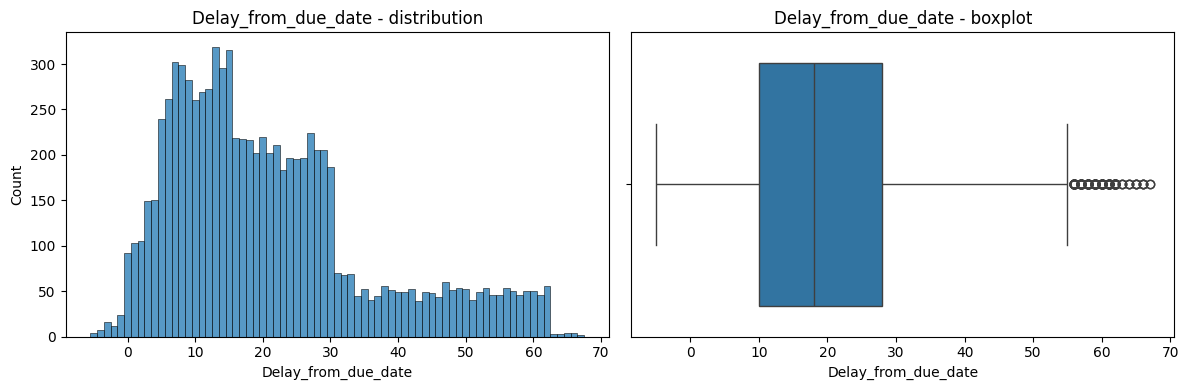

count    8504.000000
mean       21.099012
std        14.996501
min        -5.000000
25%        10.000000
50%        18.000000
75%        28.000000
max        67.000000
Name: Delay_from_due_date, dtype: float64


In [34]:
s = (
  financials_cleaned_df
  .select("Delay_from_due_date")
  .dropna()
  .toPandas()["Delay_from_due_date"]
  )

lo, hi = int(s.min()), int(s.max())
bins = np.arange(lo, hi + 2) - 0.5

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.histplot(s, bins=bins, ax=axes[0])
axes[0].set_title("Delay_from_due_date - distribution")
sns.boxplot(x=s, ax=axes[1])
axes[1].set_title("Delay_from_due_date - boxplot")
plt.tight_layout()
plt.show()

print(s.describe())

In [35]:
financials_cleaned_df.groupBy("Num_of_Delayed_Payment").count().orderBy(F.desc("count")).show()

+----------------------+-----+
|Num_of_Delayed_Payment|count|
+----------------------+-----+
|                    19|  531|
|                    15|  491|
|                    17|  487|
|                    18|  487|
|                    16|  472|
|                    10|  471|
|                    12|  467|
|                     8|  457|
|                    20|  450|
|                     9|  439|
|                    11|  425|
|                    14|  373|
|                    13|  358|
|                     7|  231|
|                    21|  229|
|                     6|  228|
|                    22|  204|
|                     5|  193|
|                    23|  190|
|                     2|  183|
+----------------------+-----+
only showing top 20 rows


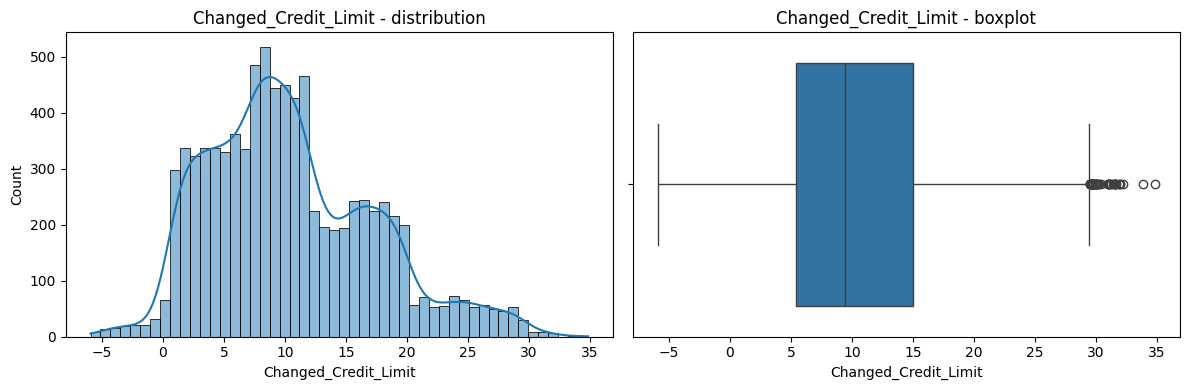

count    8504.000000
mean       10.434072
std         6.779953
min        -5.930000
25%         5.390000
50%         9.465000
75%        15.020000
max        34.849998
Name: Changed_Credit_Limit, dtype: float64


In [36]:
credit_limit = (
  financials_cleaned_df
  .select("Changed_Credit_Limit")
  .dropna()
  .toPandas()["Changed_Credit_Limit"]
)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

sns.histplot(credit_limit, bins=50, kde=True, ax=axes[0])
axes[0].set_title("Changed_Credit_Limit - distribution")
axes[0].set_xlabel("Changed_Credit_Limit")

sns.boxplot(x=credit_limit, ax=axes[1])
axes[1].set_title("Changed_Credit_Limit - boxplot")

plt.tight_layout()
plt.show()

print(credit_limit.describe())

In [37]:
financials_cleaned_df.groupBy("Num_Credit_Inquiries").count().orderBy(F.desc("count")).show()

+--------------------+-----+
|Num_Credit_Inquiries|count|
+--------------------+-----+
|                 4.0|  852|
|                 6.0|  723|
|                 7.0|  722|
|                 8.0|  700|
|                 5.0|  681|
|                 3.0|  651|
|                 2.0|  578|
|                 9.0|  555|
|                11.0|  500|
|                10.0|  481|
|                 1.0|  443|
|                12.0|  424|
|                 0.0|  363|
|                13.0|  243|
|                14.0|  176|
|                15.0|  146|
|                16.0|   86|
|                17.0|   50|
|               439.0|    2|
|              1194.0|    2|
+--------------------+-----+
only showing top 20 rows


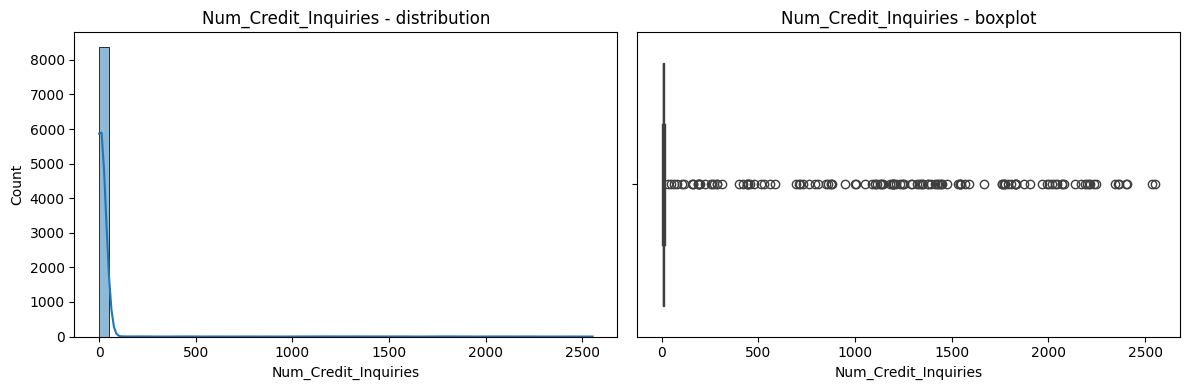

count    8504.000000
mean       25.103951
std       170.889857
min         0.000000
25%         4.000000
50%         6.000000
75%        10.000000
max      2553.000000
Name: Num_Credit_Inquiries, dtype: float64


In [38]:
credit_inquiries = (
  financials_cleaned_df
  .select("Num_Credit_Inquiries")
  .dropna()
  .toPandas()["Num_Credit_Inquiries"]
)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

sns.histplot(credit_inquiries, bins=50, kde=True, ax=axes[0])
axes[0].set_title("Num_Credit_Inquiries - distribution")
axes[0].set_xlabel("Num_Credit_Inquiries")

sns.boxplot(x=credit_inquiries, ax=axes[1])
axes[1].set_title("Num_Credit_Inquiries - boxplot")

plt.tight_layout()
plt.show()

print(credit_inquiries.describe())

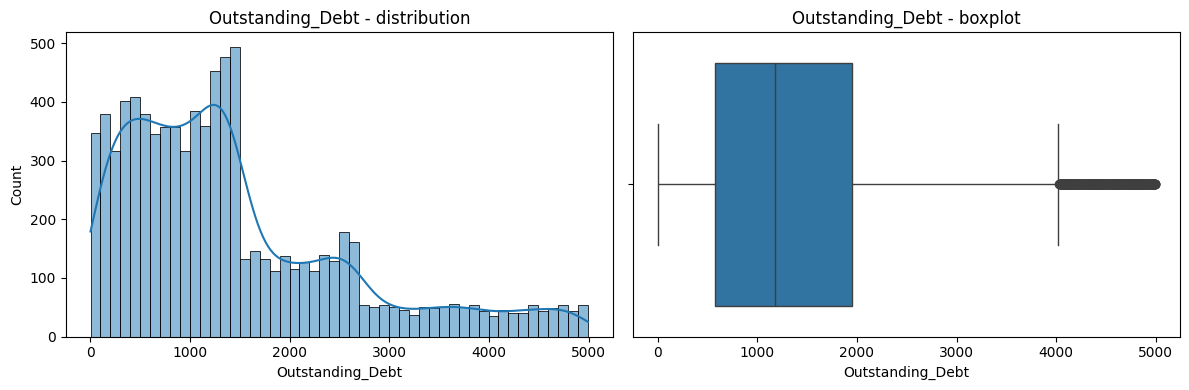

count    8504.000000
mean     1434.044922
std      1158.275513
min         0.340000
25%       572.454987
50%      1174.369995
75%      1954.742493
max      4992.250000
Name: Outstanding_Debt, dtype: float64


In [39]:
out_debt = (
  financials_cleaned_df
  .select("Outstanding_Debt")
  .dropna()
  .toPandas()["Outstanding_Debt"]
)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

sns.histplot(out_debt, bins=50, kde=True, ax=axes[0])
axes[0].set_title("Outstanding_Debt - distribution")
axes[0].set_xlabel("Outstanding_Debt")

sns.boxplot(x=out_debt, ax=axes[1])
axes[1].set_title("Outstanding_Debt - boxplot")

plt.tight_layout()
plt.show()

print(out_debt.describe())

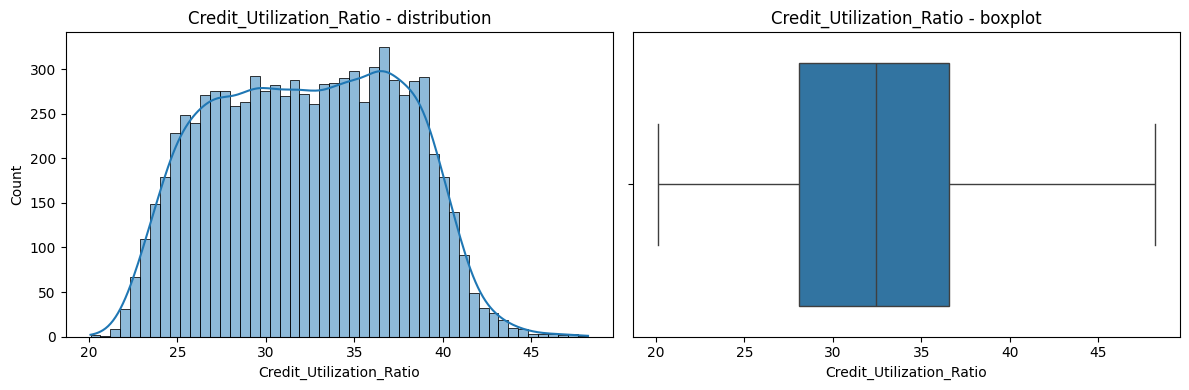

count    8504.000000
mean       32.339642
std         5.133313
min        20.100769
25%        28.071542
50%        32.406784
75%        36.557409
max        48.199825
Name: Credit_Utilization_Ratio, dtype: float64


In [40]:
credit_ratio = (
  financials_cleaned_df
  .select("Credit_Utilization_Ratio")
  .dropna()
  .toPandas()["Credit_Utilization_Ratio"]
)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

sns.histplot(credit_ratio, bins=50, kde=True, ax=axes[0])
axes[0].set_title("Credit_Utilization_Ratio - distribution")
axes[0].set_xlabel("Credit_Utilization_Ratio")

sns.boxplot(x=credit_ratio, ax=axes[1])
axes[1].set_title("Credit_Utilization_Ratio - boxplot")

plt.tight_layout()
plt.show()

print(credit_ratio.describe())

In [41]:
financials_cleaned_df.groupBy("Total_EMI_per_month").count().orderBy(F.desc("count")).show()

[Stage 85:>                                                       (0 + 12) / 12]

+-------------------+-----+
|Total_EMI_per_month|count|
+-------------------+-----+
|                0.0|  883|
|          35.013702|    1|
|           72.12381|    1|
|           77.96876|    1|
|          54.408592|    1|
|          169.87616|    1|
|          177.27711|    1|
|           117.8403|    1|
|          342.49457|    1|
|           56.64916|    1|
|           67.76528|    1|
|           76.80902|    1|
|          89.061554|    1|
|          43.229607|    1|
|          17.434952|    1|
|           95.71838|    1|
|          154.41025|    1|
|          39.212006|    1|
|          176.57935|    1|
|          311.40002|    1|
+-------------------+-----+
only showing top 20 rows


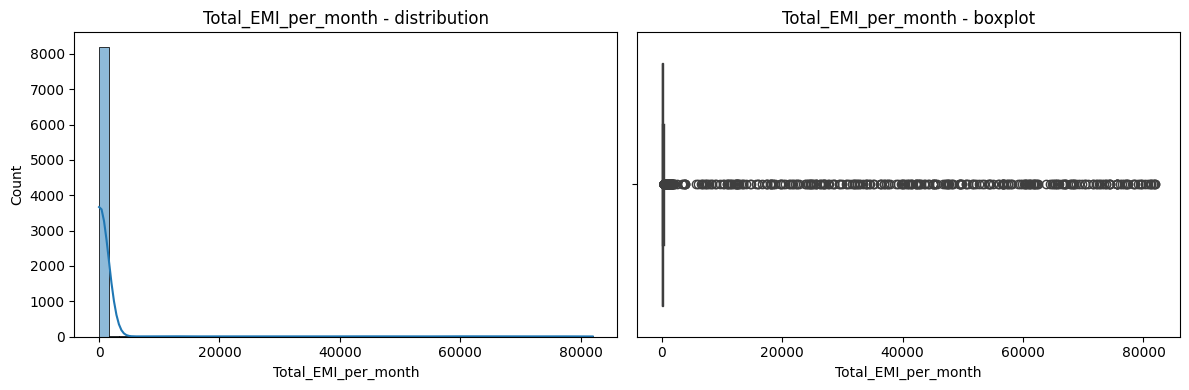

count     8504.000000
mean      1589.837891
std       8873.648438
min          0.000000
25%         30.870622
50%         72.007645
75%        169.330990
max      81971.000000
Name: Total_EMI_per_month, dtype: float64


In [42]:
emi = (
  financials_cleaned_df
  .select("Total_EMI_per_month")
  .dropna()
  .toPandas()["Total_EMI_per_month"]
)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

sns.histplot(emi, bins=50, kde=True, ax=axes[0])
axes[0].set_title("Total_EMI_per_month - distribution")
axes[0].set_xlabel("Total_EMI_per_month")

sns.boxplot(x=emi, ax=axes[1])
axes[1].set_title("Total_EMI_per_month - boxplot")

plt.tight_layout()
plt.show()

print(emi.describe())

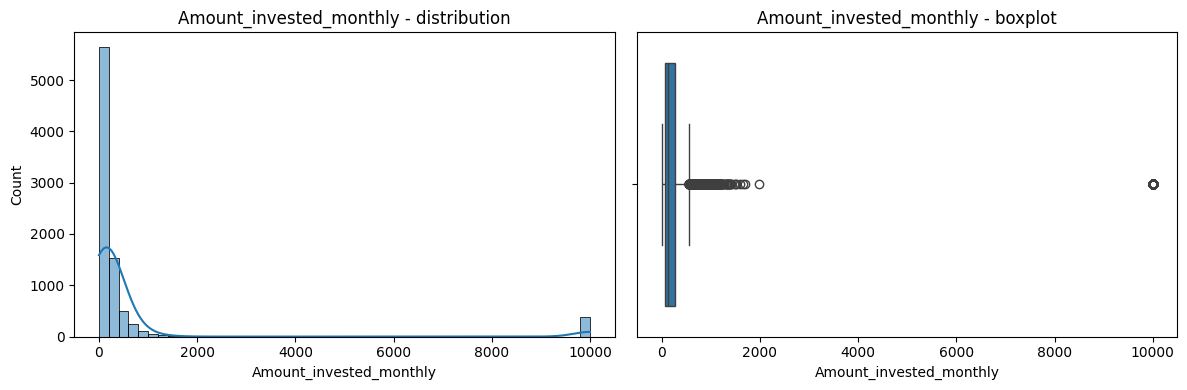

count     8504.000000
mean       638.306152
std       2048.064209
min          0.000000
25%         73.775869
50%        133.829758
75%        263.853302
max      10000.000000
Name: Amount_invested_monthly, dtype: float64


In [43]:
amt = (
  financials_cleaned_df
  .select("Amount_invested_monthly")
  .dropna()
  .toPandas()["Amount_invested_monthly"]
)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

sns.histplot(amt, bins=50, kde=True, ax=axes[0])
axes[0].set_title("Amount_invested_monthly - distribution")
axes[0].set_xlabel("Amount_invested_monthly")

sns.boxplot(x=amt, ax=axes[1])
axes[1].set_title("Amount_invested_monthly - boxplot")

plt.tight_layout()
plt.show()

print(amt.describe())

In [44]:
financials_cleaned_df.groupBy("Monthly_Balance").count().orderBy(F.desc("count")).show()

[Stage 90:=========>                                              (2 + 10) / 12]

+---------------+-----+
|Monthly_Balance|count|
+---------------+-----+
|      479.72736|    2|
|      373.11896|    2|
|      312.99075|    2|
|      444.77283|    2|
|      395.52243|    2|
|      277.91998|    1|
|      326.88193|    1|
|      305.54947|    1|
|      82.615105|    1|
|       527.8896|    1|
|      247.84981|    1|
|       56.49654|    1|
|      293.54123|    1|
|      345.38843|    1|
|      289.54492|    1|
|       244.9522|    1|
|      147.16335|    1|
|       1317.773|    1|
|      420.00034|    1|
|       662.7945|    1|
+---------------+-----+
only showing top 20 rows


### Sanity bound

In [45]:
# IQR = Q3 − Q1
# Tukey upper fence (1.5·IQR)

def tukey_upper_fence(df, column, k=1.5):
  q1, q3 = df.approxQuantile(column, [0.25, 0.75], 0.001)
  iqr = q3 - q1
  fence = q3 + k * iqr
  print(f"{column}: Q1={q1:.2f}, Q3={q3:.2f}, IQR={iqr:.2f}, upper_fence({k}·IQR)={fence:.2f}")
  return fence

In [46]:
cols_to_filter = [
  "Num_Bank_Accounts",
  "Num_Credit_Card",
  "Interest_Rate",
  "Num_of_Loan",
  "Delay_from_due_date",
  "Num_of_Delayed_Payment",
  "Changed_Credit_Limit",
  "Outstanding_Debt",
  "Num_Credit_Inquiries",
  "Total_EMI_per_month",
  "Amount_invested_monthly",
]

fences = {c: tukey_upper_fence(financials_cleaned_df, c) for c in cols_to_filter}

print("\nFilter ranges (Tukey 1.5·IQR upper fence):\n")
for c, upper in fences.items():
  print(f"  .filter(col(\"{c}\").between(0, {upper:.2f}))")

# apply the filters
for c, upper in fences.items():
  financials_cleaned_df = financials_cleaned_df.filter(col(c).between(0, upper))

print("\nrows after filtering:", financials_cleaned_df.count())

Num_Bank_Accounts: Q1=3.00, Q3=7.00, IQR=4.00, upper_fence(1.5·IQR)=13.00
Num_Credit_Card: Q1=4.00, Q3=7.00, IQR=3.00, upper_fence(1.5·IQR)=11.50
Interest_Rate: Q1=8.00, Q3=20.00, IQR=12.00, upper_fence(1.5·IQR)=38.00
Num_of_Loan: Q1=1.00, Q3=5.00, IQR=4.00, upper_fence(1.5·IQR)=11.00
Delay_from_due_date: Q1=10.00, Q3=28.00, IQR=18.00, upper_fence(1.5·IQR)=55.00
Num_of_Delayed_Payment: Q1=9.00, Q3=18.00, IQR=9.00, upper_fence(1.5·IQR)=31.50
Changed_Credit_Limit: Q1=5.38, Q3=14.98, IQR=9.60, upper_fence(1.5·IQR)=29.38
Outstanding_Debt: Q1=570.40, Q3=1948.99, IQR=1378.59, upper_fence(1.5·IQR)=4016.87
Num_Credit_Inquiries: Q1=4.00, Q3=10.00, IQR=6.00, upper_fence(1.5·IQR)=19.00
Total_EMI_per_month: Q1=30.75, Q3=168.77, IQR=138.02, upper_fence(1.5·IQR)=375.80
Amount_invested_monthly: Q1=73.57, Q3=262.86, IQR=189.29, upper_fence(1.5·IQR)=546.80

Filter ranges (Tukey 1.5·IQR upper fence):

  .filter(col("Num_Bank_Accounts").between(0, 13.00))
  .filter(col("Num_Credit_Card").between(0, 11.50

In [47]:
# filter out outliers based on the visualisation and row count

financials_cleaned_df = (
    financials_cleaned_df
    
    .filter(col("Num_Bank_Accounts").between(0, 10))
    .filter(col("Num_Credit_Card").between(0, 10))
    .filter(col("Interest_Rate").between(0, 34))
    .filter(col("Num_of_Loan").between(0, 9))
    .filter(col("Delay_from_due_date").between(0, 55))
    .filter(col("Num_of_Delayed_Payment").between(0, 25))
    .filter(col("Changed_Credit_Limit").between(0, 30))
    .filter(col("Outstanding_Debt").between(0, 4500))
    .filter(col("Num_Credit_Inquiries").between(0, 18))
    .filter(col("Total_EMI_per_month").between(0, 370))
    .filter(col("Amount_invested_monthly").between(0, 420))
)


In [49]:
df = spark.read.option("recursiveFileLookup", "true").parquet("datamart/gold/feature_store_customer/")

df.filter(col("Type_of_Loan").isNull()) \
.select("Num_of_Loan") \
.groupBy("Num_of_Loan") \
.count() \
.orderBy("Num_of_Loan") \
.show()

[Stage 131:>                                                      (0 + 12) / 12]

+-----------+-----+
|Num_of_Loan|count|
+-----------+-----+
|          0|  565|
+-----------+-----+

